## 1. Introducción

##### hola



## 2. Importación de librerias


In [2]:
import pandas as pd
import numpy as np

from pathlib import Path

import matplotlib.pyplot as plt



## 3. Carga de datos

In [3]:
RUTA = Path("./Data/raw")

dim_conductor = pd.read_csv(RUTA / "dim_conductor.csv")
dim_depot = pd.read_csv(RUTA / "dim_depot.csv")
dim_linea = pd.read_csv(RUTA / "dim_linea.csv")
dim_parada = pd.read_csv(RUTA / "dim_parada.csv")
dim_tarifa = pd.read_csv(RUTA / "dim_tarifa.csv")
dim_vehiculo = pd.read_csv(RUTA / "dim_vehiculo.csv")
 
fact_incidencias = pd.read_csv(RUTA / "fact_incidencias.csv")
fact_mantenimiento = pd.read_csv(RUTA / "fact_mantenimiento.csv")
fact_viajes = pd.read_csv(RUTA / "fact_viajes.csv")

## 4. Exploración inicial


### - dimensiones

##### En este apartado se realiza una primera revisión de cada una de las tablas del conjunto de datos con el objetivo de conocer su estructura, el volumen de información disponible y los tipos de datos de cada variable. Esta exploración permitirá detectar posibles incidencias antes de comenzar el análisis exploratorio.


In [4]:
tablas = {
    "dim_conductor": dim_conductor,
    "dim_depot": dim_depot,
    "dim_linea": dim_linea,
    "dim_parada": dim_parada,
    "dim_tarifa": dim_tarifa,
    "dim_vehiculo": dim_vehiculo,
    "fact_incidencias": fact_incidencias,
    "fact_mantenimiento": fact_mantenimiento,
    "fact_viajes": fact_viajes
}

for nombre, tabla in tablas.items():
    print(f"{nombre}: {tabla.shape}")

dim_conductor: (30, 10)
dim_depot: (3, 6)
dim_linea: (10, 7)
dim_parada: (120, 10)
dim_tarifa: (9, 6)
dim_vehiculo: (45, 12)
fact_incidencias: (4000, 16)
fact_mantenimiento: (876, 15)
fact_viajes: (50000, 24)


##### Interpretación
##### Con estos resultados vemos que las tablas de dimensiones contienen un número reducido registros, a excepción de dim_paradas que siendo reducido aporta 120 registros muy superior a las demas tablas de dimensiones. Mientras que las tablas de de hechos contienen un número muy elevado llegando hasta los 50000 registros en una tabla, lo cual es coherente con la estructura de un modelo dimensional destinado al análisis de datos.

### - tipos
#### En este apartado vamos a valorar los tipos de datos que nos aportan las tablas buscando algun valor nulo.

In [5]:
for nombre, tabla in tablas.items():
    print("="*60)
    print(nombre)
    tabla.info()

dim_conductor
<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   conductor_id        30 non-null     int64  
 1   nombre              30 non-null     str    
 2   anno_incorporacion  30 non-null     int64  
 3   antiguedad_anos     29 non-null     float64
 4   turno_habitual      30 non-null     str    
 5   depot_id            30 non-null     int64  
 6   formacion           30 non-null     str    
 7   licencia_tipo       30 non-null     str    
 8   activo              30 non-null     bool   
 9   ausencias_2024      30 non-null     int64  
dtypes: bool(1), float64(1), int64(4), str(4)
memory usage: 3.5 KB
dim_depot
<class 'pandas.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   depot_id             3 non-null    

#### Interpretación
#### Viendo los resultados podemos apreciar que hay varias columnas en diferentes tablas que deberian de ser bool y sin embargo son object o str, lo curioso es que también hay columnas de bool. Por último, hay una columna fecha que aparece como str y no como datetime, supongo que sera igual y el motivo es por como está escrito.
#### Por otro lado, en la tabla dim_parada en la columna latitud hay 119 datos de 120. En la tabla fact_mantenimiento en la columna categoria hay 861 datos de 876. Y por último en la tabla fact_viajes hay dos columnas; pasajeros_subidos que tiene 49960 datos de 50000 y consumo que tiene 48935 datos de 50000.


### - primeras filas
#### En este apartado vamos a analizar las primeras filas y ver que los valores y las columnas sean acordes a la tabla.

In [6]:
for nombre, tabla in tablas.items():
    print("="*60)
    print(nombre)
    display(tabla.head())

dim_conductor


,conductor_id,nombre,anno_incorporacion,antiguedad_anos,turno_habitual,depot_id,formacion,licencia_tipo,activo,ausencias_2024
0,1,Carlos Garcia,2009,15.0,Partido,3,Basica,D,True,14
1,2,Maria Lopez,2013,11.0,Noche (22-06h),1,Basica,D,True,9
2,3,Juan Martinez,2008,16.0,Manana (06-14h),2,Completa,D+E,True,6
3,4,Ana Fernandez,2007,17.0,manana,1,Basica + Articulado,D,True,1
4,5,Pedro Sanchez,2016,8.0,Partido,3,Basica + Articulado,D,True,10


dim_depot


,depot_id,nombre,barrio,latitud,longitud,capacidad_vehiculos
0,1,Cochera Norte,Barrio Norte,40.440,-3.720,20
1,2,Cochera Central,Centro,40.418,-3.700,15
2,3,Cochera Sur,Barrio Sur,40.395,-3.695,12


dim_linea


...

,incidencia_id,viaje_id,vehiculo_id,conductor_id,linea_id,fecha,anno,mes,hora_incidencia,tipo_incidencia,categoria,severidad,requiere_retirada,duracion_resolucion_min,vehiculo_sustituto,coste_estimado_eur
0,1,33554,39,11,4,2022-06-01,2022,6,19:11,Huelga parcial,Operacional,Alta,True,60,False,0.00
1,2,9428,21,21,6,2023-02-16,2023,2,20:42,Fallo electrico,Vehiculo,Alta,True,62,False,575.51
2,3,200,33,5,8,2022-01-20,2022,1,06:21,Accidente leve,Seguridad,Alta,True,29,True,3318.00
3,4,12448,17,17,10,2023-01-16,2023,1,02:30,Vandalismo,Seguridad,Media,False,16,False,651.99
4,5,39490,11,11,6,2023-01-08,2023,1,14:51,Retencion trafico,Externo,Baja,False,14,False,49.88


fact_mantenimiento


,mantenimiento_id,vehiculo_id,depot_id,fecha_entrada,fecha_salida,anno,mes,tipo_mantenimiento,categoria,es_correctivo,dias_fuera_servicio,km_en_revision,coste_eur,proveedor,garantia_meses
0,1,1,1,2024-07-24,2024-07-25,2024,7,Cambio aceite,Preventivo,False,1,278454,218.70,TallerBus Norte,0
1,2,1,1,2023-02-08,2023-02-09,2023,2,Cambio neumaticos,Preventivo,False,1,240059,1068.93,TallerBus Norte,0
2,3,1,1,2024-10-28,2024-10-29,2024,10,Cambio neumaticos,Preventivo,False,1,493071,722.19,Taller Oficial Mercedes,0
3,4,1,1,2022-08-01,2022-08-03,2022,8,Reparacion clima,Correctivo,True,2,533556,579.93,FlotaService,6
4,5,1,1,2024-12-09,2024-12-10,2024,12,Revision bateria,Preventivo,False,1,307110,436.54,TallerBus Norte,0


fact_viajes


,viaje_id,linea_id,vehiculo_id,conductor_id,parada_origen_id,parada_destino_id,fecha,anno,mes,dia_semana,...,hora_llegada_real,retraso_salida_min,duracion_real_min,pasajeros_subidos,ocupacion_pct,km_programados,km_recorridos,viaje_completado,consumo,tarifa_predominante_id
0,1,4,2,2,17,116,2023-08-14,2023,8,Monday,...,19:22,19,73,78.0,0.609,14.1,14.1,True,4.69,4
1,2,4,3,3,5,48,2024-05-20,2024,5,Monday,...,08:30,13,67,115.0,0.885,14.1,14.1,True,5.86,2
2,3,5,4,4,33,110,2023-08-15,2023,8,Tuesday,...,13:05,0,35,47.0,0.362,7.3,7.3,True,3.15,3
3,4,2,5,5,37,116,2022-03-23,2022,3,Wednesday,...,21:36,0,46,111.0,0.888,11.2,11.2,True,3.50,9
4,5,5,6,6,12,115,2022-03-24,2022,3,Thursday,...,18:50,8,32,75.0,0.405,7.3,7.3,True,3.13,3


#### Interpretación
#### En este apartado podemos apreciar como se ven todas las tablas bien ordenadas y los datos son acordes.

### Conclusión de la exploración incial
#### Tras revisar las dimensiones, los tipos de datos y las primeras filas de todas las tablas se observa que el conjunto de datos presenta una estructura coherente y adecuada para su análisis.

#### Se han detectado algunos valores nulos o celdas vacias. Sin embargo, se han identificado algunas columnas cuyos tipos de datos podrían optimizarse durante la fase de limpieza, especialmente variables booleanas almacenadas como texto y columnas de fechas importadas como cadenas de caracteres, aunque pandas a leido todos bien y se ven como True/false.


## 5. Calidad de datos

### 5.1 Completitud

In [8]:
def resumen_nulos(df, nombre):
    nulos = df.isnull().sum()
    total = len(df)
    porcentaje = (nulos / total) * 100
    
    return pd.DataFrame({
        "columna": df.columns,
        "nulos": nulos,
        "porcentaje": porcentaje
    }).query("nulos > 0")

resumen_nulos(fact_viajes, "fact_viajes")

,columna,nulos,porcentaje
pasajeros_subidos,pasajeros_subidos,40,0.08
consumo,consumo,1065,2.13


In [9]:
def resumen_nulos(df, nombre):
    nulos = df.isnull().sum()
    total = len(df)
    porcentaje = (nulos / total) * 100
    
    return pd.DataFrame({
        "columna": df.columns,
        "nulos": nulos,
        "porcentaje": porcentaje
    }).query("nulos > 0")

resumen_nulos(dim_conductor, "dim_conductor")

,columna,nulos,porcentaje
antiguedad_anos,antiguedad_anos,1,3.333333


In [11]:
def resumen_nulos(df, nombre):
    nulos = df.isnull().sum()
    total = len(df)
    porcentaje = (nulos / total) * 100
    
    return pd.DataFrame({
        "columna": df.columns,
        "nulos": nulos,
        "porcentaje": porcentaje
    }).query("nulos > 0")

resumen_nulos(dim_parada, "dim_parada")

,columna,nulos,porcentaje
latitud,latitud,1,0.833333
accesible_silla,accesible_silla,1,0.833333


#### Se detectan dos tabla con valores nulos, dim_conductor y fact_viajes. Unicamente en una columna en una y dos en la otra.
#### En el caso de consumo, los valores nulos representan aproximadamente un 2% del total. Por otro lado, la columna de antiguedad_anos los valores nulos representan un valor superior al 3% pero este se debe a que el dato tendria que ser 0 porque el trabajador no lleva mas de un año de antiguedad.
#### En general el data set presenta un alto nivel de completitud.

### 5.2 Consistencia

In [23]:
fact_viajes.info()
dim_parada.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   viaje_id                50000 non-null  int64  
 1   linea_id                50000 non-null  int64  
 2   vehiculo_id             50000 non-null  int64  
 3   conductor_id            50000 non-null  int64  
 4   parada_origen_id        50000 non-null  int64  
 5   parada_destino_id       50000 non-null  int64  
 6   fecha                   50000 non-null  str    
 7   anno                    50000 non-null  int64  
 8   mes                     50000 non-null  int64  
 9   dia_semana              50000 non-null  str    
 10  es_festivo              50000 non-null  bool   
 11  franja_horaria          50000 non-null  str    
 12  hora_salida_prog        50000 non-null  str    
 13  hora_salida_real        50000 non-null  str    
 14  hora_llegada_real       50000 non-null  str    
 

#### Detectamos unicamente dos columnas en las cuales el typo del dato no es el correcto. En la tabla dim_parada tenemos la columna accesible_silla que marca un tipo de dato object y deberia ser bool ya que en las casillas tiene marcado true/false. Por otro lado, en la tabla fact_viaje la columana de fecha indica que es object y deberia de ser un datetime, para poder operar con ella. Si es cierto de que cara la visualización de Power BI tenemos ano y mes que nos ayudaran a mostrar esos datos con mayor calidad y eso puede ser el motivo por el sea de esta manera.
#### Se recomienda una conversión de tipos en la fase de limpieza de datos

### 5.3 Unicidad

### En esta apartado vamos a comprobar que los valores sean unicos y no se repitan.

In [24]:
for nombre, df in tablas.items():
    print(f"\n🔹 {nombre}")
    print("Duplicados filas:", df.duplicated().sum())


🔹 dim_conductor
Duplicados filas: 0

🔹 dim_depot
Duplicados filas: 0

🔹 dim_linea
Duplicados filas: 0

🔹 dim_parada
Duplicados filas: 0

🔹 dim_tarifa
Duplicados filas: 0

🔹 dim_vehiculo
Duplicados filas: 0

🔹 fact_incidencias
Duplicados filas: 0

🔹 fact_mantenimiento
Duplicados filas: 0

🔹 fact_viajes
Duplicados filas: 0


In [26]:
dim_conductor["conductor_id"].duplicated().sum()
dim_linea["linea_id"].duplicated().sum()
dim_parada["parada_id"].duplicated().sum()
dim_vehiculo["vehiculo_id"].duplicated().sum()
fact_incidencias["incidencia_id"].duplicated().sum()
fact_mantenimiento["mantenimiento_id"].duplicated().sum()
fact_viajes["viaje_id"].duplicated().sum()

np.int64(0)

#### Se ha analizado la unicidad de los datos tanto en tablas dimensionales como en tablas de hechos.
#### En las tablas de dimensiones detectamos que no hay claves primarias duplicadas, que son valores unicos.
#### En las tablas de hechos tampoco encontramos valores duplicados, lo que indica que cada fila es un evento.
#### En conjunto, el dataset presenta una adecuada unicidad.

### 5.4 Validez

### En este apartado vamos a comprobar que los datos son validos comparandolos con el resto de la tabla.

In [12]:
fact_viajes["ocupacion_pct"].min(), fact_viajes["ocupacion_pct"].max()


(np.float64(0.005), np.float64(0.995))

#### Comprobamos que la ocupación está entre 0 y 1 y estan dentro del rango esperado

In [18]:
fact_incidencias.groupby(
    ["tipo_incidencia", "severidad"]
)[["duracion_resolucion_min", "coste_estimado_eur"]].describe()

duracion_resolucion_min                        \
                                                count       mean        std   
tipo_incidencia     severidad                                                 
Accidente grave     Critica                     328.0  44.762195  47.521103   
Accidente leve      Alta                        332.0  42.141566  40.283750   
Averia mecanica     Alta                        347.0  41.253602  45.629815   
Condiciones meteo   Media                       382.0  16.950262  14.929234   
Fallo climatizacion Baja                        312.0  18.557692  17.438082   
Fallo electrico     Alta                        332.0  41.813253  38.833537   
Huelga parcial      Alta                        339.0  48.581121  50.666228   
Obras calzada       Media                       340.0  17.535294  16.267362   
Pasajero enfermo    Media                       311.0  17.064309  14.917052   
Pinchazo            Media                       335.0  18.253731  16.275458   
Retencion trafico   Baja                        312.0  19.032051  18.117665   
Vandalismo          Media                       330.0  16.718182  15.319177   

                                                               \
                               min    25%   50%    75%    max   
tipo_incidencia     severidad                                   
Accidente grave     Critica    5.0   9.00  27.5  62.00  288.0   
Accidente leve      Alta       5.0  12.75  30.0  55.00  267.0   
Averia mecanica     Alta       5.0  11.00  26.0  55.00  333.0   
Condiciones meteo   Media      5.0   5.00  12.0  23.75   92.0   
Fallo climatizacion Baja       5.0   5.00  12.0  25.00  104.0   
Fallo electrico     Alta       5.0  11.00  30.0  61.00  234.0   
Huelga parcial      Alta       5.0  10.00  32.0  70.00  254.0   
Obras calzada       Media      5.0   5.00  11.0  23.00  107.0   
Pasajero enfermo    Media      5.0   5.00  12.0  22.00   83.0   
Pinchazo            Media      5.0   5.00  13.0  25.00  121.0   
Retencion trafico   Baja       5.0   5.00  12.0  25.25  104.0   
Vandalismo          Media      5.0   5.00  12.0  20.00   98.0   

                              coste_estimado_eur                            \
                                           count         mean          std   
tipo_incidencia     severidad                                                
Accidente grave     Critica                328.0  8470.416982  3868.042981   
Accidente leve      Alta                   332.0  2286.725211   992.772242   
Averia mecanica     Alta                   347.0  1616.965677   805.066800   
Condiciones meteo   Media                  382.0     0.000000     0.000000   
Fallo climatizacion Baja                   312.0   170.893494    73.105069   
Fallo electrico     Alta                   332.0  1169.687440   499.616846   
Huelga parcial      Alta                   339.0     0.000000     0.000000   
Obras calzada       Media                  340.0     0.000000     0.000000   
Pasajero enfermo    Media                  311.0    53.679743    28.721420   
Pinchazo            Media                  335.0   240.493373    92.939412   
Retencion trafico   Baja                   312.0    24.580673    14.579869   
Vandalismo          Media                  330.0   454.354273   201.181769   

                                                                         \
                                   min        25%       50%         75%   
tipo_incidencia     severidad                                             
Accidente grave     Critica    2004.83  4955.7150  8785.505  11827.6225   
Accidente leve      Alta        511.82  1369.8900  2292.220   3159.5700   
Averia mecanica     Alta        202.76   900.2700  1675.960   2332.6500   
Condiciones meteo   Media         0.00     0.0000     0.000      0.0000   
Fallo climatizacion Baja         50.30   107.5550   168.545    236.0425   
Fallo electrico     Alta        301.88   699.7025  1195.890   1603.4350   
Huelga parcial      Al

#### Analizamos el conjunto de los datos de duración de resolución y el coste que repreentan estos datos.Podemos observar que los tiempos no concuerdan perfectamente con todos los aprtados. Ya que observamos como para un pinchazo el tiempo en minutos puede ser adecuado, pero para un accidente grave 288 minutos representa una reparación de menos de 5 horas.
#### Analizando un poco más a fondo en la tabla encontramos los costes que pueden tener accidentes graves valorados de criticos, con cotes altos y con una resolución hiper rapida por estar en minutos.

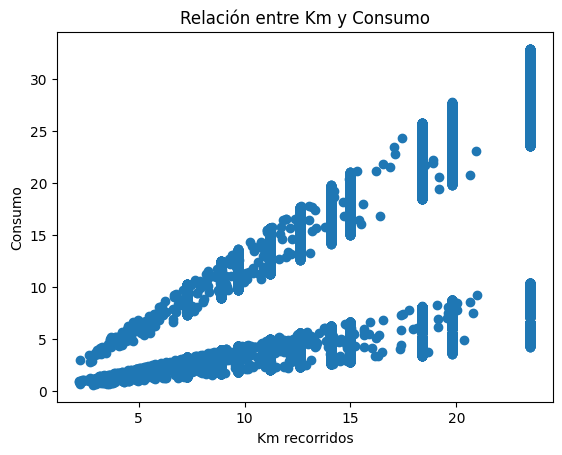

In [14]:
import matplotlib.pyplot as plt

plt.scatter(fact_viajes["km_recorridos"], fact_viajes["consumo"])
plt.xlabel("Km recorridos")
plt.ylabel("Consumo")
plt.title("Relación entre Km y Consumo")
plt.show()


#### Aquí podemos observar como los consumos tienen una relación positiva entre consumo y los km recorridos, lo cual es coherente. Destacamos dos agrupaciones ascendentes. Estas agrupaciones podrían corresponder a diferentes tipos de vehiculos utilizados, aunque con está información no está explicitamente definido en el dataset. Tienen un crecimiento regular y acorde con los esperado.

#### 5.5 Coherencia entre tablas

In [10]:
fact_viajes[~fact_viajes["linea_id"].isin(dim_linea["linea_id"])]
# conductor
fact_viajes[~fact_viajes["conductor_id"].isin(dim_conductor["conductor_id"])]

# vehiculo
fact_viajes[~fact_viajes["vehiculo_id"].isin(dim_vehiculo["vehiculo_id"])]

# parada
fact_viajes[~fact_viajes["parada_origen_id"].isin(dim_parada["parada_id"])]

,viaje_id,linea_id,vehiculo_id,conductor_id,parada_origen_id,parada_destino_id,fecha,anno,mes,dia_semana,...,hora_llegada_real,retraso_salida_min,duracion_real_min,pasajeros_subidos,ocupacion_pct,km_programados,km_recorridos,viaje_completado,consumo,tarifa_predominante_id


In [11]:
fact_viajes.groupby("linea_id")["km_recorridos"].mean().reset_index().merge(
    dim_linea[["linea_id", "km_recorrido"]],
    on="linea_id"
)

,linea_id,km_recorridos,km_recorrido
0,1,18.294094,18.4
1,2,11.104960,11.2
2,3,9.611045,9.7
3,4,13.994711,14.1
4,5,7.237638,7.3
5,6,23.337365,23.5
6,7,8.823016,8.9
7,8,12.489418,12.6
8,9,19.682010,19.8
9,10,14.882014,15.0


In [12]:
fact_viajes["ocupacion_pct"].describe()

count    50000.000000
mean         0.455362
std          0.264251
min          0.005000
25%          0.227000
50%          0.422000
75%          0.688000
max          0.995000
Name: ocupacion_pct, dtype: float64

In [13]:
fact_viajes["tarifa_predominante_id"].isin(dim_tarifa["tarifa_id"]).value_counts()

tarifa_predominante_id
True    50000
Name: count, dtype: int64

#### Viendo los resultados podemos interpretar que la mayoria de los registros de viajes tienen correspondencia con tarifas existentes, lo que indica coherencia entre ambas tablas.

#### En general, las relaciones entre tablas son consistentes y permiten establecer un modelo relacional coherente. No obstante, se detectan pequeñas discrepancias en algunas variables como los kilómetros recorridos, lo que sugiere posibles inconsistencias o variabilidad en los datos operativos.

## 6. Outliers


In [5]:
fact_viajes.describe()

,viaje_id,linea_id,vehiculo_id,conductor_id,parada_origen_id,parada_destino_id,anno,mes,retraso_salida_min,duracion_real_min,pasajeros_subidos,ocupacion_pct,km_programados,km_recorridos,consumo,tarifa_predominante_id
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,49960.000000,50000.000000,50000.000000,50000.000000,48935.000000,50000.000000
mean,25000.500000,5.502600,21.496000,14.498800,20.547780,80.454760,2023.000380,6.518820,3.89218,62.600340,61.283907,0.455362,14.014620,13.910457,7.695104,3.606020
std,14433.901067,2.865665,12.120814,8.077258,11.562176,23.126044,0.816917,3.448467,6.76309,23.849155,36.847517,0.264251,4.949592,4.999930,6.221862,2.160808
min,1.000000,1.000000,1.000000,1.000000,1.000000,41.000000,2022.000000,1.000000,-99.00000,25.000000,1.000000,0.005000,7.300000,2.200000,0.550000,1.000000
25%,12500.750000,3.000000,11.000000,7.000000,11.000000,60.000000,2022.000000,4.000000,1.00000,44.000000,30.000000,0.227000,9.700000,9.700000,3.600000,2.000000
50%,25000.500000,6.000000,21.000000,14.000000,21.000000,80.500000,2023.000000,7.000000,2.00000,58.000000,56.000000,0.422000,12.600000,12.600000,5.340000,3.000000
75%,37500.250000,8.000000,32.000000,21.000000,31.000000,100.000000,2024.000000,10.000000,5.00000,78.000000,91.000000,0.688000,18.400000,18.400000,9.080000,5.000000
max,50000.000000,10.000000,42.000000,28.000000,40.000000,120.000000,2024.000000,12.000000,50.00000,129.000000,184.000000,0.995000,23.500000,23.500000,32.860000,9.000000


In [6]:
fact_viajes["duracion_real_min"].sort_values(ascending=False).head()

2369     129
35445    129
41007    129
2351     129
30746    129
Name: duracion_real_min, dtype: int64

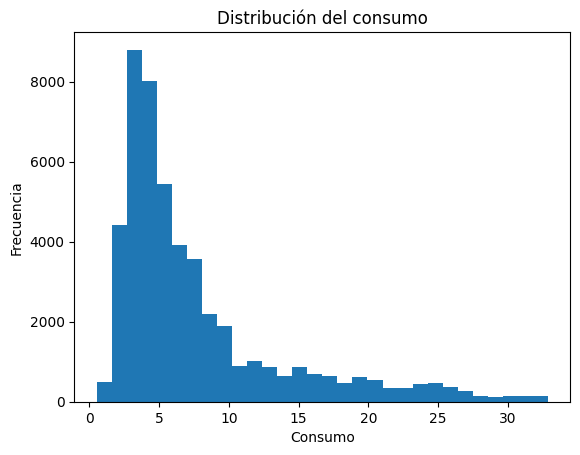

In [7]:
import matplotlib.pyplot as plt

plt.hist(fact_viajes["consumo"].dropna(), bins=30)
plt.title("Distribución del consumo")
plt.xlabel("Consumo")
plt.ylabel("Frecuencia")
plt.show()

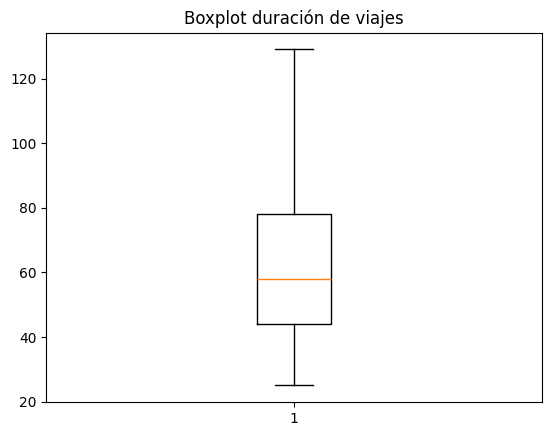

In [8]:
plt.boxplot(fact_viajes["duracion_real_min"].dropna())
plt.title("Boxplot duración de viajes")
plt.show()

#### Se detectan valores extremos en la duración de los viajes que superan ampliamente la media, lo que sugiere la presencia de outliers o posibles errores en los datos.


## 9. Conclusiones

#### A lo largo del análisis exploratorio se ha realizado una revisión completa del dataset, evaluando la calidad de los datos, su estructura y la coherencia entre variables y tablas.

En primer lugar, se ha comprobado que los datos presentan una estructura consistente, con relaciones claras entre tablas de hechos y dimensiones. No se han detectado problemas relevantes de duplicados y, en general, las claves primarias y foráneas mantienen la integridad del modelo.

Sin embargo, se han identificado varios aspectos a tener en cuenta:

Existen valores nulos en determinadas variables como el consumo, lo que dificulta su interpretación.
Se han detectado inconsistencias en los tipos de datos, especialmente en variables booleanas y fechas, que aparecen como texto.
Se observan posibles incoherencias en variables operativas, como duraciones de incidencias demasiado bajas para su nivel de severidad.
En el análisis de relaciones entre variables, se identifican patrones coherentes (como la relación entre kilómetros y consumo), aunque con posibles agrupaciones que sugieren diferencias no documentadas en el dataset.

En cuanto a los outliers, se han detectado valores extremos en variables como duración de viajes y consumo, lo que podría indicar errores en la generación de los datos o casos excepcionales.

Finalmente, se concluye que el dataset es adecuado para su análisis, aunque requiere un proceso previo de limpieza y transformación para garantizar la calidad de los resultados en fases posteriores del proyecto.

Como hipótesis, se considera que parte de las inconsistencias detectadas podrían haber sido introducidas de forma intencionada con fines didácticos.